## Importing library

In [1]:
import pandas as pd
import numpy as np

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
plt.style.use("seaborn-v0_8")
sns.set_palette("viridis")

## Loading dataset

In [4]:
df = pd.read_csv("data/Unemployment in India.csv")
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


## Inspect the Dataset

### Shape

In [5]:
df.shape

(768, 7)

### Info and describe

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB


In [7]:
df.describe()

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740.000000,7.400000e+02,740.000000
mean,11.787946,7.204460e+06,42.630122
std,10.721298,8.087988e+06,8.111094
min,0.000000,4.942000e+04,13.330000
25%,4.657500,1.190404e+06,38.062500
50%,8.350000,4.744178e+06,41.160000
75%,15.887500,1.127549e+07,45.505000
max,76.740000,4.577751e+07,72.570000


### Checking null values

In [8]:
df.isnull().sum()

Region                                      28
 Date                                       28
 Frequency                                  28
 Estimated Unemployment Rate (%)            28
 Estimated Employed                         28
 Estimated Labour Participation Rate (%)    28
Area                                        28
dtype: int64

### Visualize missing data patterns

In [9]:
import missingno

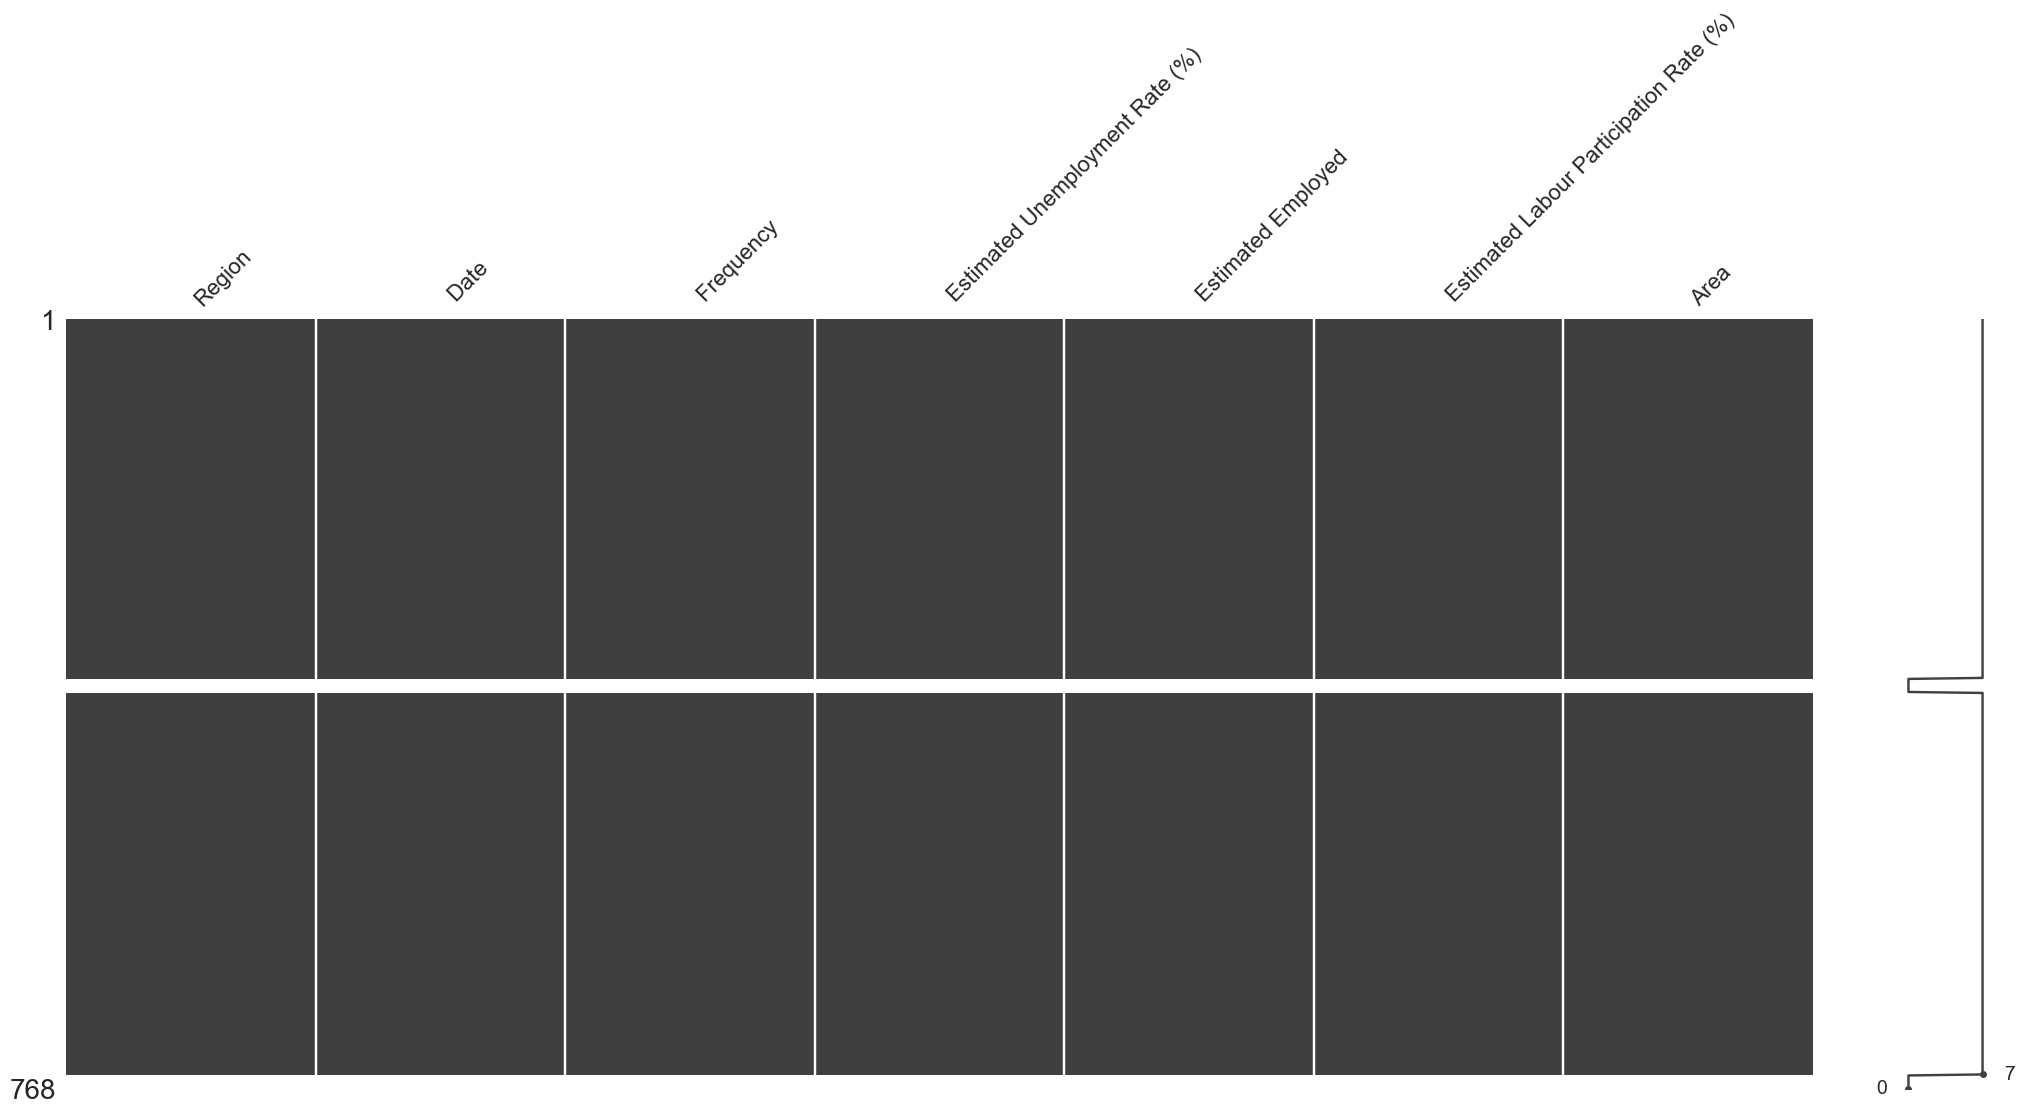

In [10]:
missingno.matrix(df)
plt.show()

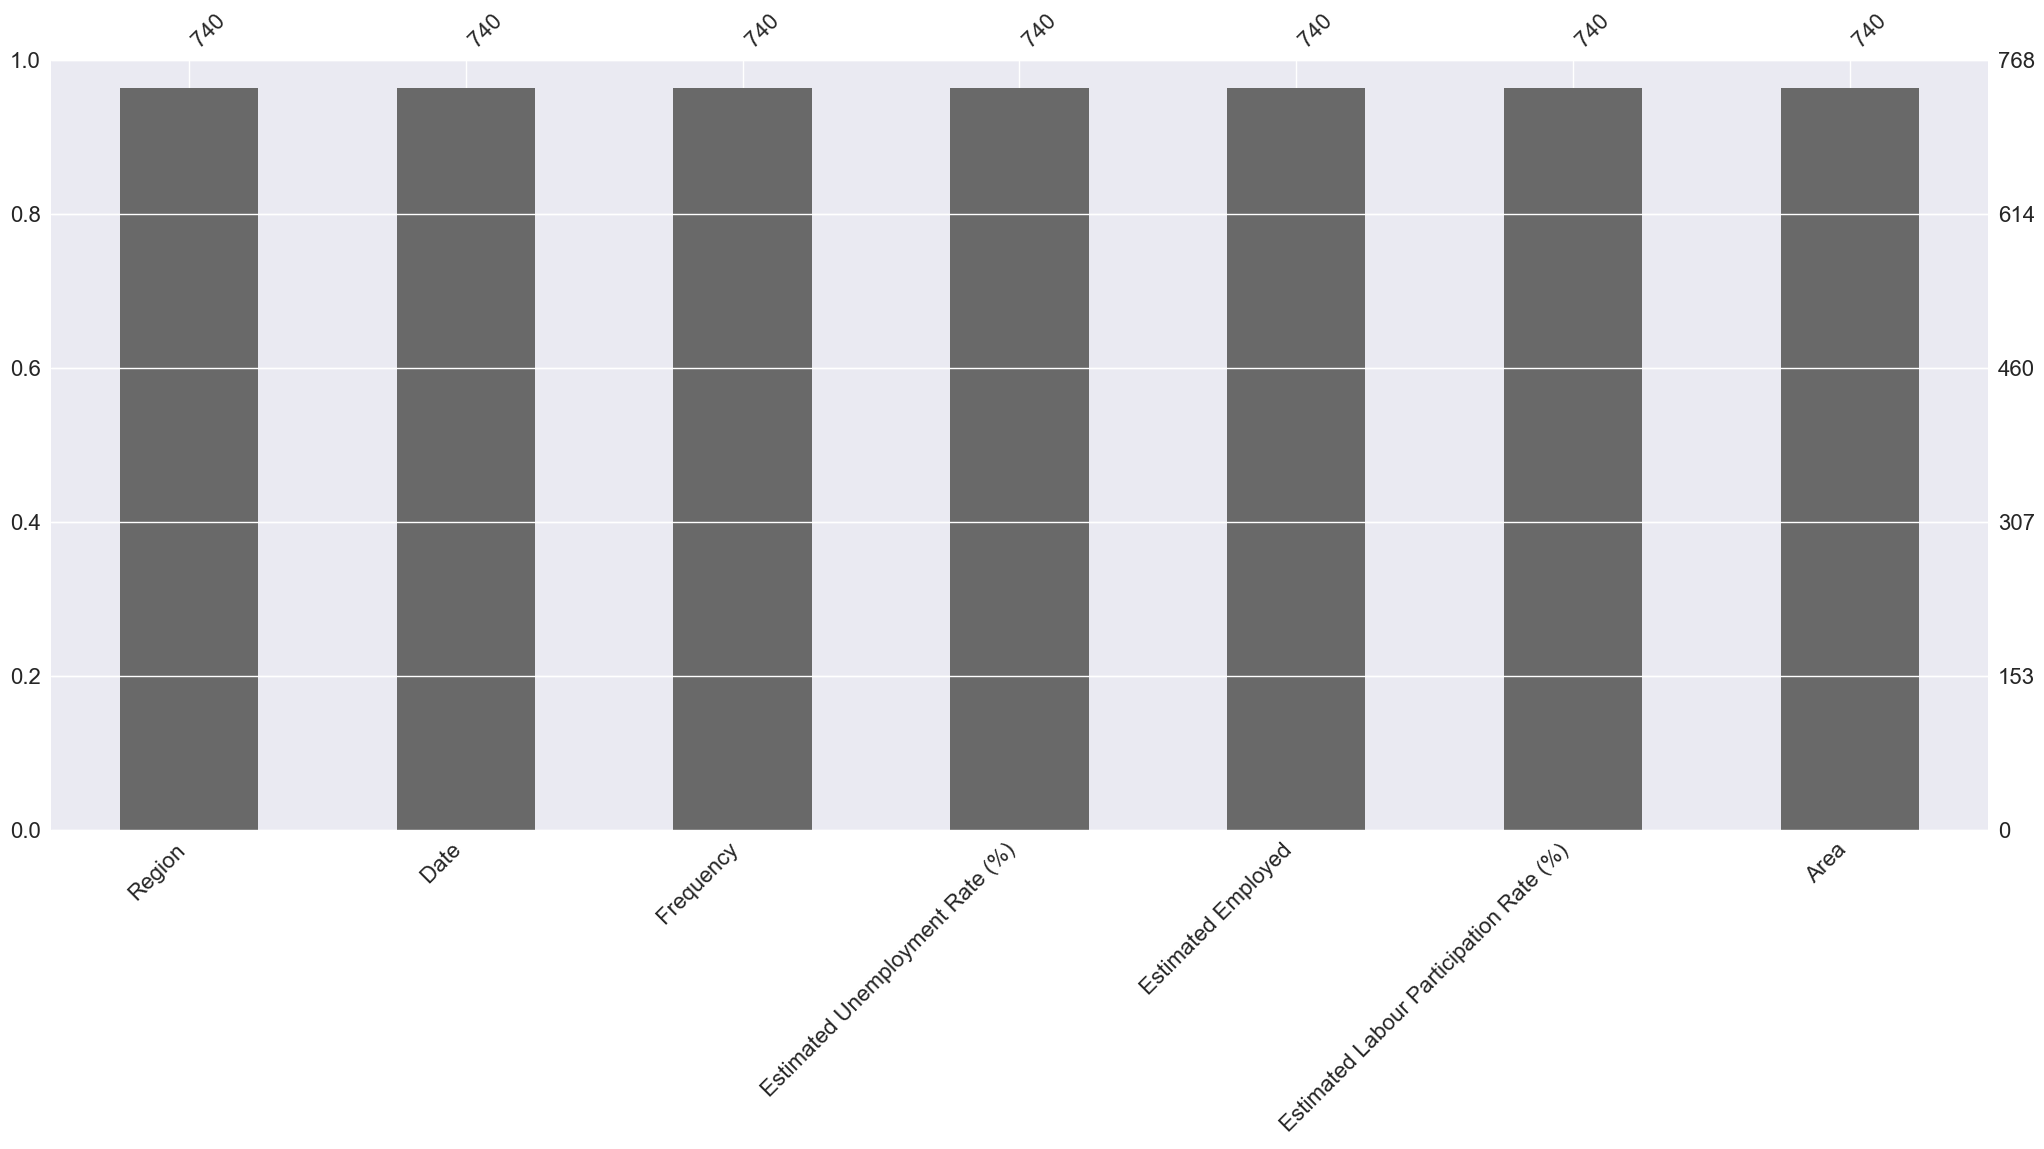

In [11]:
missingno.bar(df)
plt.show()

In [12]:
df.dropna(inplace=True, ignore_index=True)

## Cleaning the Dataset

In [13]:
df.columns = df.columns.str.strip()

In [14]:
df.columns

Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')

### Renaming column names

In [15]:
df.rename(columns={
    'Estimated Unemployment Rate (%)':'Unemployment',
    'Estimated Employed':'Employed',
    'Estimated Labour Participation Rate (%)':'LabourParticipation'
}, inplace=True)

### Convert Date column.

In [16]:
df['Date'] = pd.to_datetime(df['Date'], errors="coerce")

C:\Users\user\AppData\Local\Temp\ipykernel_42712\2581419108.py:1: UserWarning: Parsing dates in  %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Date'] = pd.to_datetime(df['Date'], errors="coerce")


In [17]:
df.isnull().sum()

Region                 0
Date                   0
Frequency              0
Unemployment           0
Employed               0
LabourParticipation    0
Area                   0
dtype: int64

In [18]:
df.dtypes

Region                         object
Date                   datetime64[ns]
Frequency                      object
Unemployment                  float64
Employed                      float64
LabourParticipation           float64
Area                           object
dtype: object

## Extract Month and Year

In [19]:
df['Month'] = df['Date'].dt.month_name()
df['Year'] = df['Date'].dt.year

## Exploratory Data Analysis (EDA)

### Region-wise Average Unemployment Rate

In [20]:
region_avg = df.groupby("Region")["Unemployment"].mean().sort_values()

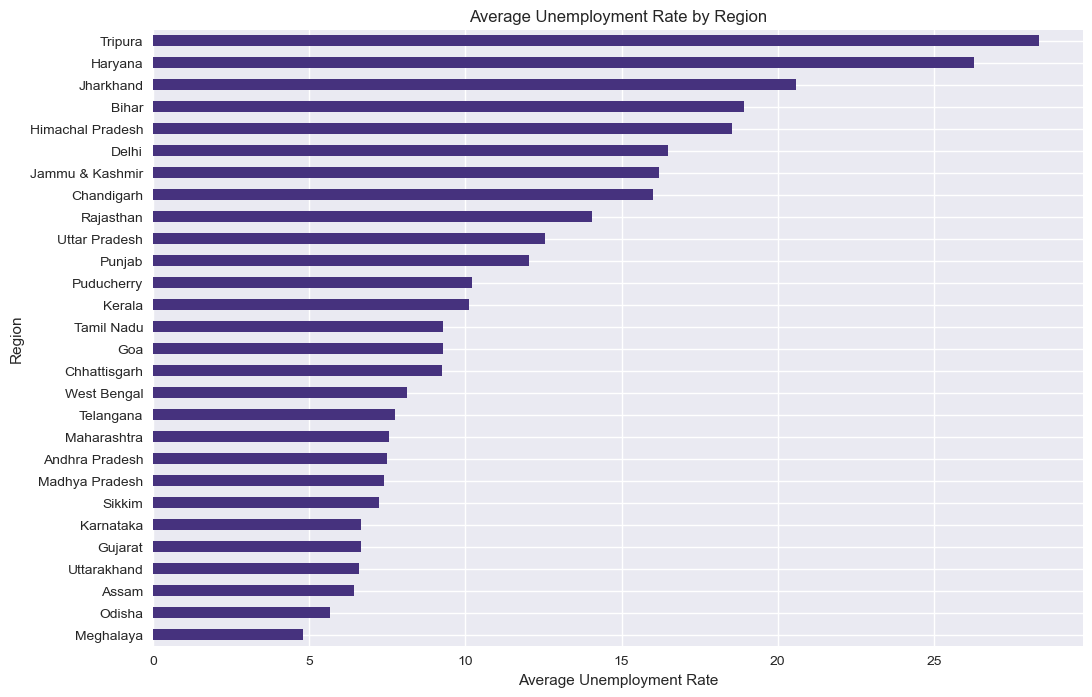

In [21]:
plt.figure(figsize=(12,8))

region_avg.plot(kind='barh')

plt.xlabel("Average Unemployment Rate")
plt.title("Average Unemployment Rate by Region")

plt.show()

### Observation

*Some regions like Tripura, Haryana and Jharkhand consistently experience higher unemployment than others, indicating regional economic disparities.*

### Month-wise Unemployment Trend

In [22]:
monthly = df.groupby("Month")["Unemployment"].mean()

In [23]:
months = ['January','February','March','April','May','June', 'July','August','September','October','November','December']
monthly = monthly.reindex(months)

In [24]:
monthly

Month
January       9.950755
February      9.964717
March        10.700577
April        23.641569
May          16.646190
June         10.553462
July          9.033889
August        9.637925
September     9.051731
October       9.900909
November      9.868364
December      9.497358
Name: Unemployment, dtype: float64

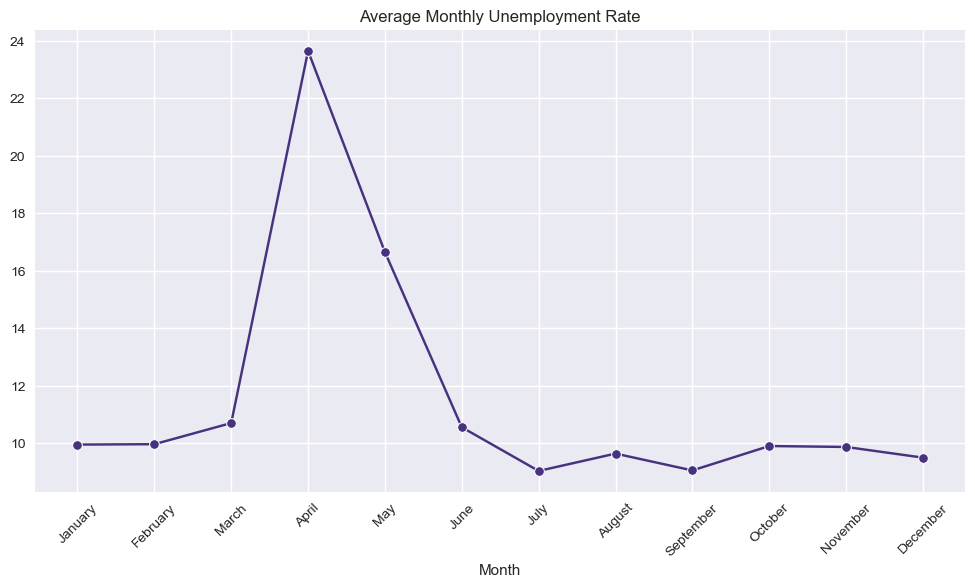

In [25]:
plt.figure(figsize=(12,6))

sns.lineplot(x=monthly.index,
             y=monthly.values,
             marker='o')

plt.xticks(rotation=45)

plt.title("Average Monthly Unemployment Rate")

plt.show()

### Observation

*Unemployment increased sharply during month in **April** corresponding to the COVID lockdown period, and declined slightly in May.*

## Time-Series Analysis for Three Major States

In [26]:
states = ["Maharashtra","Karnataka","Tamil Nadu"]
state_df = df[df["Region"].isin(states)]

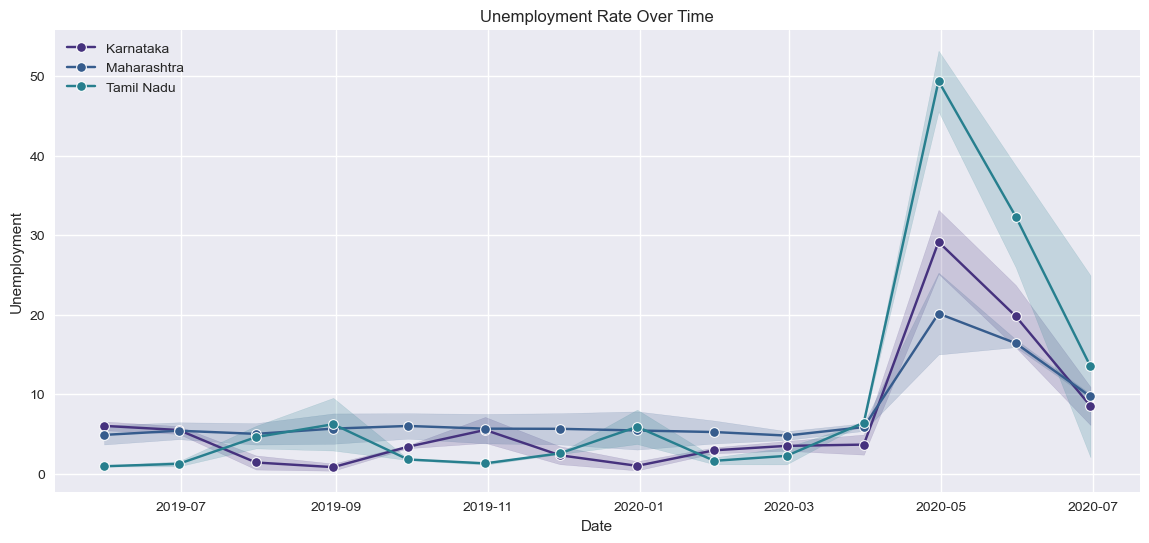

In [27]:
plt.figure(figsize=(14,6))

sns.lineplot(data=state_df, x="Date", y="Unemployment", hue="Region", marker="o")

plt.title("Unemployment Rate Over Time")
plt.legend(loc ="upper left")

plt.show()


### Observation

*Tamil Nadu experienced the highest spike during lockdown, while Karnataka recovered more quickly.*

## Top 10 States with Highest Average Unemployment

In [28]:
top10 = (df.groupby("Region")["Unemployment"].mean().sort_values(ascending=False).head(10))
top10

Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Name: Unemployment, dtype: float64

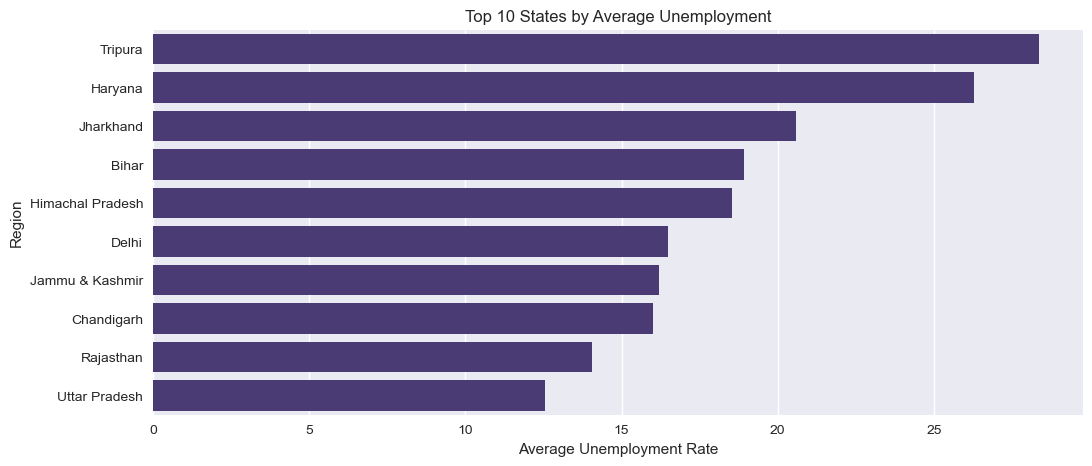

In [29]:
plt.figure(figsize=(12,5))

sns.barplot(x=top10.values,y=top10.index)

plt.xlabel("Average Unemployment Rate")
plt.title("Top 10 States by Average Unemployment")
plt.show()

## Correlation Heatmap

In [30]:
selected_cols = ['Unemployment','Employed','LabourParticipation']
corr = df[selected_cols].corr()

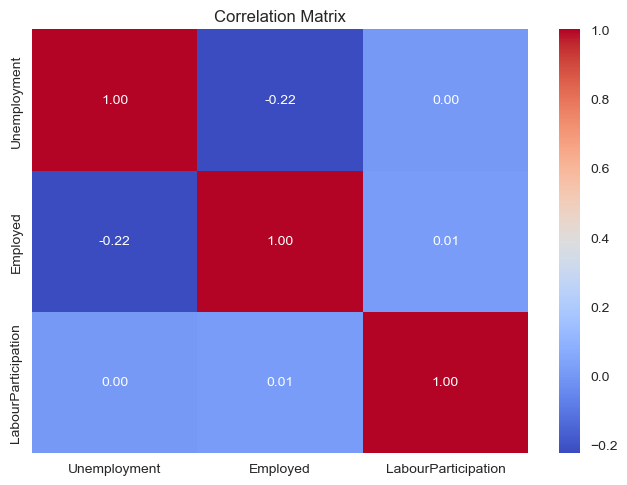

In [31]:
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

## Observation

*There is no relation between any of the parameter.*

## Pre-COVID vs Post-COVID Comparison
#### COVID period starts around March 2020.

In [32]:
pre = df[df["Date"] < "2020-03-01"]
post = df[df["Date"] >= "2020-03-01"]

### Computing averages

In [33]:
comparison = pd.DataFrame({"Pre-COVID":[pre["Unemployment"].mean()],
                           "Post-COVID":[post["Unemployment"].mean()] 
                          })
comparison

,Pre-COVID,Post-COVID
0,9.509534,17.774363


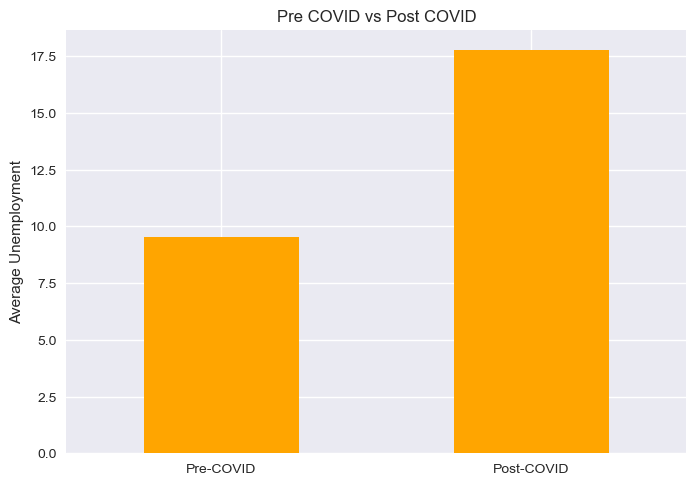

In [34]:
comparison.T.plot(kind="bar", legend=False, color=["orange"] )

plt.ylabel("Average Unemployment")
plt.xticks(rotation = 0)
plt.title("Pre COVID vs Post COVID")

plt.show()

## Additional Insights

### Boxplot of rural vs urbam

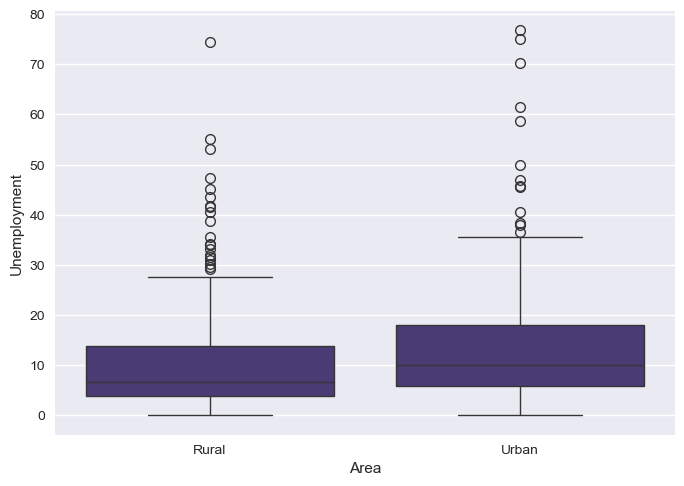

In [35]:
sns.boxplot(data=df, x="Area", y="Unemployment")
plt.show()

### Ditribution plot

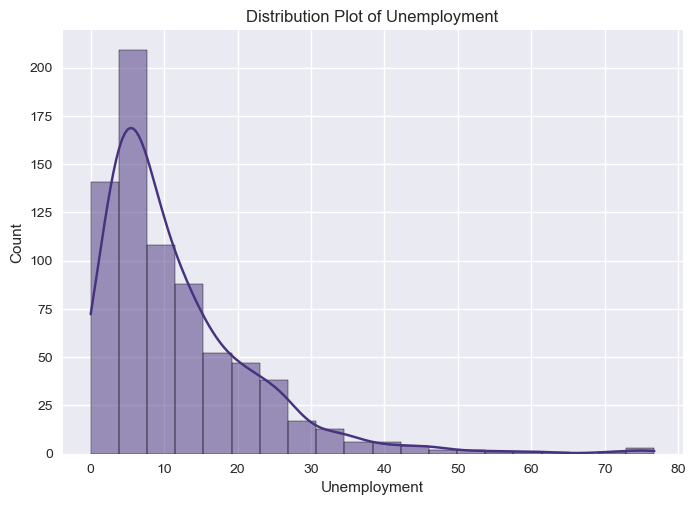

In [38]:
sns.histplot(df["Unemployment"], bins=20, kde=True)
plt.title("Distribution Plot of Unemployment")
plt.show()

## Pairplot


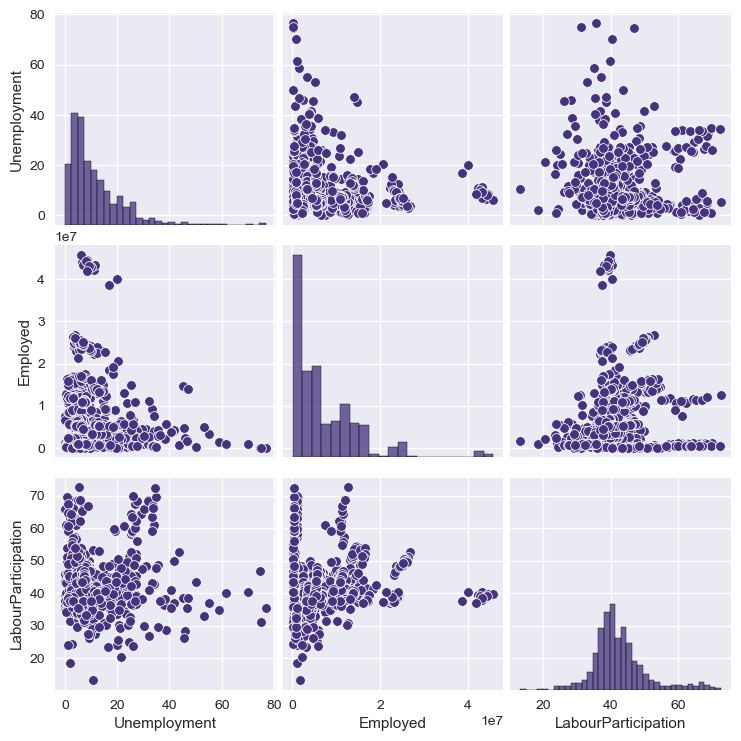

In [37]:
sns.pairplot(df[selected_cols])
plt.show()